cell 1 - imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from transformers import (
    BertTokenizer,
    BertModel,
    RobertaTokenizer,
    RobertaModel
)

import sys
sys.path.append("..")

from src.extraction import load_word_contexts
from src.embeddings import get_word_embedding
from src.similarity import average_similarity
from src.mev import compute_mev

cell 2 -Load models

In [2]:
# BERT

bert_tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

bert_model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_hidden_states=True
)

bert_model.eval()


# RoBERTa

roberta_tokenizer = RobertaTokenizer.from_pretrained(
    "roberta-base"
)

roberta_model = RobertaModel.from_pretrained(
    "roberta-base",
    output_hidden_states=True
)

roberta_model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=Tru

cell 3 - words

In [3]:
target_words = [
    "bank",
    "plant",
    "spring"
]

cell 4 - Load contexts

In [4]:
contexts_by_word = {}

for word in target_words:

    contexts = load_word_contexts(
        word
    )

    contexts_by_word[word] = contexts

    print(
        word,
        len(contexts)
    )

bank 56
plant 56
spring 56


cell 5 - embedding extraction

In [5]:
def extract_embeddings_for_word(
    contexts,
    word,
    tokenizer,
    model
):

    all_embeddings = []

    for context in contexts:

        emb = get_word_embedding(
            context,
            word,
            tokenizer,
            model
        )

        if emb is not None:

            all_embeddings.append(
                emb
            )

    return all_embeddings

cell 6 - self sim

In [6]:
def self_similarity_curve(
    all_embeddings
):

    n_layers = len(
        all_embeddings[0]
    )

    curve = []

    for layer_idx in range(
        n_layers
    ):

        vectors = []

        for emb in all_embeddings:

            vectors.append(
                emb[layer_idx]
            )

        vectors = np.array(
            vectors
        )

        score = average_similarity(
            vectors
        )

        curve.append(
            score
        )

    return curve

cell 7 - mev

In [7]:
def mev_curve(
    all_embeddings
):

    n_layers = len(
        all_embeddings[0]
    )

    curve = []

    for layer_idx in range(
        n_layers
    ):

        vectors = []

        for emb in all_embeddings:

            vectors.append(
                emb[layer_idx]
            )

        vectors = np.array(
            vectors
        )

        score = compute_mev(
            vectors
        )

        curve.append(
            score
        )

    return curve

cell 8 - runing both models

In [8]:
results = {}
for word in target_words:

    print(
        f"Processing {word}"
    )

    contexts = contexts_by_word[
        word
    ]

    # BERT

    bert_embeddings = (
        extract_embeddings_for_word(
            contexts,
            word,
            bert_tokenizer,
            bert_model
        )
    )

    bert_self = (
        self_similarity_curve(
            bert_embeddings
        )
    )

    bert_mev = (
        mev_curve(
            bert_embeddings
        )
    )

    # RoBERTa

    roberta_embeddings = (
        extract_embeddings_for_word(
            contexts,
            word,
            roberta_tokenizer,
            roberta_model
        )
    )

    roberta_self = (
        self_similarity_curve(
            roberta_embeddings
        )
    )

    roberta_mev = (
        mev_curve(
            roberta_embeddings
        )
    )

    results[word] = {

        "bert_self":
            bert_self,

        "bert_mev":
            bert_mev,

        "roberta_self":
            roberta_self,

        "roberta_mev":
            roberta_mev
    }

Processing bank
Processing plant
Processing spring


cell 9 - compare self sim

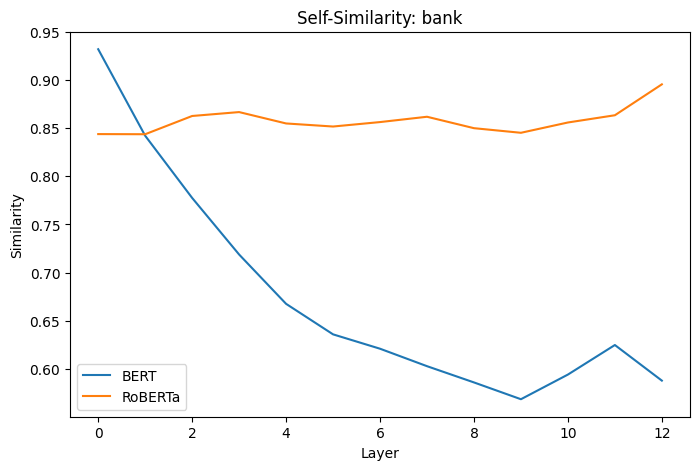

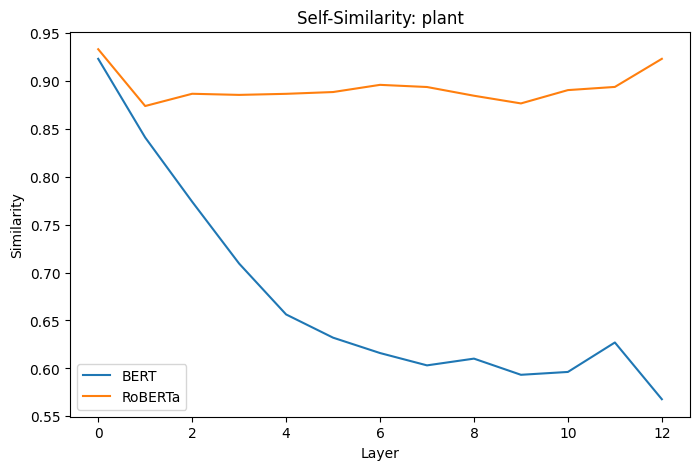

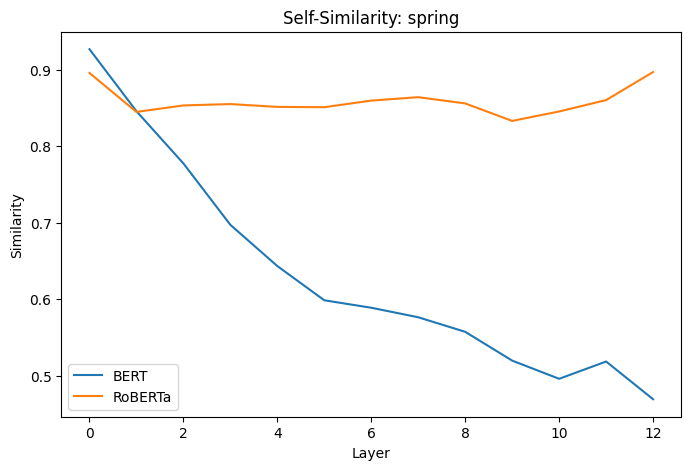

In [9]:
for word in target_words:

    plt.figure(
        figsize=(8,5)
    )

    plt.plot(
        results[word]["bert_self"],
        label="BERT"
    )

    plt.plot(
        results[word]["roberta_self"],
        label="RoBERTa"
    )

    plt.title(
        f"Self-Similarity: {word}"
    )

    plt.xlabel(
        "Layer"
    )

    plt.ylabel(
        "Similarity"
    )

    plt.legend()

    plt.show()

cell 10 - compare mev

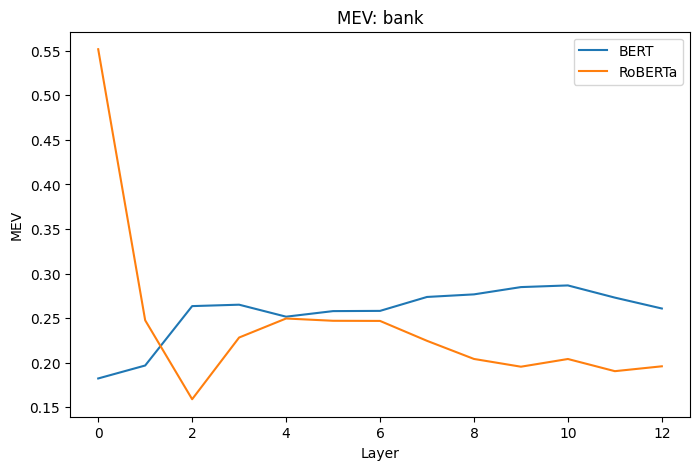

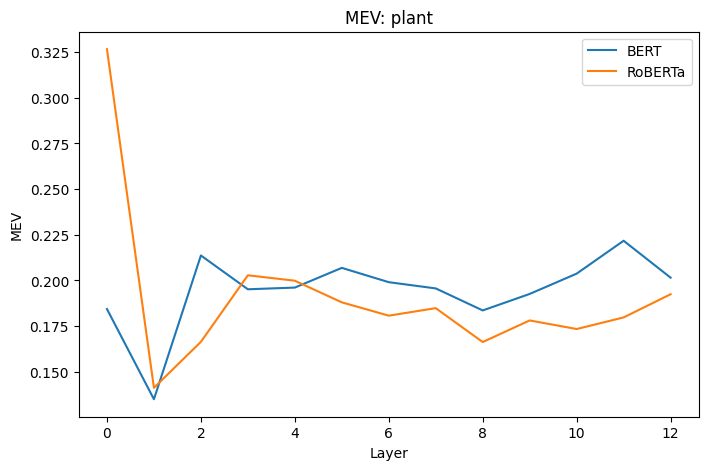

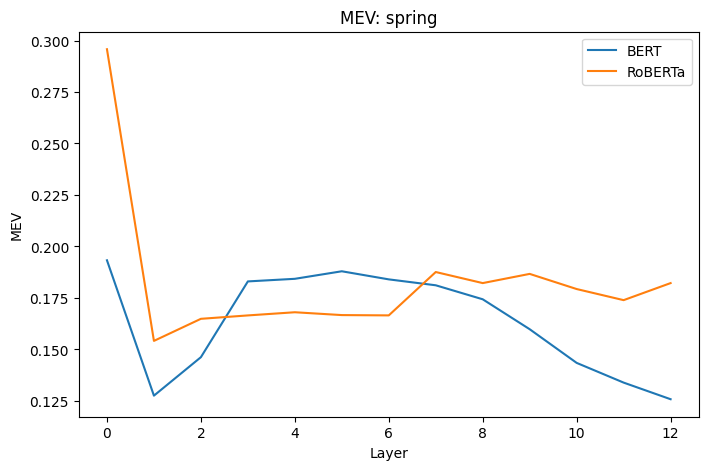

In [10]:
for word in target_words:

    plt.figure(
        figsize=(8,5)
    )

    plt.plot(
        results[word]["bert_mev"],
        label="BERT"
    )

    plt.plot(
        results[word]["roberta_mev"],
        label="RoBERTa"
    )

    plt.title(
        f"MEV: {word}"
    )

    plt.xlabel(
        "Layer"
    )

    plt.ylabel(
        "MEV"
    )

    plt.legend()

    plt.show()

BERT and RoBERTa exhibit markedly different layer-wise dynamics for polysemous words. BERT progressively separates contextual occurrences, resulting in decreasing self-similarity across layers. In contrast, RoBERTa maintains highly stable representations while distributing contextual information across the embedding space, as reflected by consistently high self-similarity and low MEV values.